# Political Bias Evaluation Pipeline (Staged)

This notebook restructures political-bias analysis into explicit stages so we can see **how each stage changes totals** across all videos.

## Objective
Evaluate all videos for political bias while keeping a cumulative tally at each stage:

1. Baseline (all unknown)
2. Topic coverage
3. Lexicon-only framing
4. Lexicon + tags
5. Lexicon + tags + guest signal
6. Final resolved label and confidence
7. Unknown queue for manual review

The notebook uses the existing classified output as source-of-truth for signals and then rebuilds stage transitions for auditability.


## 0 - Setup and data contracts


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


def find_project_root(marker="data/TRIGGERnometry-video-taxonomy/trigggerpod-classified.csv"):
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root containing "
        f"{marker}. Run notebook from inside the statistics-notes repo."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data/TRIGGERnometry-video-taxonomy"
CLASSIFIED_PATH = DATA_DIR / "trigggerpod-classified.csv"
UNKNOWN_REVIEW_PATH = DATA_DIR / "unknowns-review.csv"

required_columns = [
    "published_date", "title", "topics", "framing_score", "framing_label",
    "tags_framing_score", "guest_name_detected", "guest_signal",
    "combined_score", "combined_label", "signal_sources", "confidence",
]

df = pd.read_csv(CLASSIFIED_PATH, parse_dates=["published_date"])
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for c in ["framing_score", "tags_framing_score", "guest_signal", "combined_score"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

if "topics" in df.columns:
    df["n_topics"] = df["topics"].fillna("").apply(lambda x: 0 if x == "" else len(str(x).split("|")))
else:
    df["n_topics"] = 0

print(f"Project root: {PROJECT_ROOT}")
print(f"Rows: {len(df):,}")
print(f"Date range: {df['published_date'].min().date()} -> {df['published_date'].max().date()}")
print(f"Columns checked: {len(required_columns)}")
print(f"No-topic videos: {(df['n_topics'] == 0).sum():,}")


Project root: /Users/nathanormond/Dev/playground/statistics-notes
Rows: 1,849
Date range: 2018-04-23 -> 2026-03-01
Columns checked: 12
No-topic videos: 601


## 1 - Stage engine (cumulative totals + deltas)

`record_stage()` captures counts, percentages, and deltas at each stage.


In [17]:
LABEL_ORDER = ["right-leaning", "left-leaning", "contested", "neutral", "unknown"]
stage_records = []


def normalize_label(s):
    s = s.fillna("unknown").astype(str)
    s = s.where(s.isin(LABEL_ORDER), "unknown")
    return s


def record_stage(stage_name, label_series, note=""):
    labels = normalize_label(label_series)
    counts = labels.value_counts().reindex(LABEL_ORDER, fill_value=0)
    total = int(counts.sum())

    row = {
        "stage": stage_name,
        "total": total,
        "note": note,
    }
    for label in LABEL_ORDER:
        row[f"{label}_count"] = int(counts[label])
        row[f"{label}_pct"] = float(counts[label] / total * 100.0 if total else 0.0)

    if stage_records:
        prev = stage_records[-1]
        for label in LABEL_ORDER:
            row[f"delta_{label}"] = row[f"{label}_count"] - prev[f"{label}_count"]
    else:
        for label in LABEL_ORDER:
            row[f"delta_{label}"] = 0

    stage_records.append(row)


def stage_summary_df():
    return pd.DataFrame(stage_records)


def classify_from_score(score, threshold=0.5):
    if score >= threshold:
        return "right-leaning"
    if score <= -threshold:
        return "left-leaning"
    return "unknown"


## 2 - Stage definitions and cumulative tracking


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPANDED GUEST IDENTITY DICTIONARY (synced with 04-guest-interview-bias.ipynb)
# ══════════════════════════════════════════════════════════════════════════════
# (category, wing, prominence) - wing ∈ {"right", "left", "contested"}
GUEST_IDENTITY: dict[str, tuple[str, str, int]] = {
    # UK Politicians
    "Kemi Badenoch": ("Conservative", "right", 5),
    "Liz Truss": ("Conservative, libertarian right", "right", 5),
    "Nigel Farage": ("Reform UK", "right", 5),
    "Robert Jenrick": ("Reform UK", "right", 3),
    "Suella Braverman": ("Conservative", "right", 4),
    "Jacob Rees-Mogg": ("Conservative", "right", 4),
    "Claire Fox": ("Brexit Party", "right", 3),
    "Laila Cunningham": ("Reform UK", "right", 2),
    "Mahyar Tousi": ("Reform UK", "right", 2),
    # UK Right-Wing Media
    "Douglas Murray": ("Right-wing commentator", "right", 4),
    "Peter Hitchens": ("Right-wing commentator", "right", 3),
    "Andrew Doyle": ("Right-wing commentator", "right", 3),
    "Toby Young": ("Right-wing commentator", "right", 3),
    "Melanie Phillips": ("Right-wing commentator", "right", 3),
    "David Starkey": ("Right-wing commentator", "right", 3),
    "Matt Goodwin": ("Right-wing commentator", "right", 3),
    "Matthew Goodwin": ("Right-wing commentator", "right", 3),
    "Mike Graham": ("Right-wing commentator", "right", 3),
    "Patrick Christys": ("Right-wing commentator", "right", 3),
    "Julia Hartley-Brewer": ("Right-wing commentator", "right", 3),
    "Isabel Oakeshott": ("Right-wing commentator", "right", 3),
    "Dan Wootton": ("Right-wing commentator", "right", 3),
    "Fraser Nelson": ("Right-wing commentator", "right", 3),
    "Brendan O'Neill": ("Right-wing commentator", "right", 3),
    "Iain Dale": ("Conservative", "right", 2),
    "Geoff Norcott": ("Conservative", "right", 2),
    "Tom Slater": ("Right-wing commentator", "right", 2),
    "Simon Evans": ("Right-wing commentator", "right", 2),
    "Dominic Frisby": ("Right-wing commentator", "right", 2),
    "Robin Aitken": ("Right-wing commentator", "right", 2),
    # Gender Critical
    "Katharine Birbalsingh": ("Right-wing commentator", "right", 3),
    "Helen Joyce": ("Gender critical", "right", 3),
    "Kathleen Stock": ("Gender critical", "right", 3),
    "Maya Forstater": ("Gender critical", "right", 2),
    "Posie Parker": ("Gender critical", "right", 2),
    "Sharron Davies": ("Gender critical", "right", 2),
    "Graham Linehan": ("Gender critical", "right", 2),
    "Debbie Hayton": ("Gender critical", "right", 2),
    # UK Far-Right
    "Tommy Robinson": ("Far-right activist", "right", 3),
    "Laurence Fox": ("Right-wing commentator", "right", 3),
    "Count Dankula": ("Right-wing commentator", "right", 2),
    # US Right-Wing
    "Jordan Peterson": ("Right-wing commentator", "right", 5),
    "Ben Shapiro": ("Right-wing commentator", "right", 5),
    "Tucker Carlson": ("Right-wing commentator", "right", 5),
    "Joe Rogan": ("Right-wing commentator", "right", 5),
    "Tim Pool": ("Right-wing commentator", "right", 4),
    "Candace Owens": ("Right-wing commentator", "right", 4),
    "Dave Rubin": ("Right-wing commentator", "right", 3),
    "Michael Malice": ("Right-wing commentator", "right", 3),
    "Adam Carolla": ("Right-wing commentator", "right", 3),
    "Greg Gutfeld": ("Right-wing commentator", "right", 3),
    "Ann Coulter": ("Right-wing commentator", "right", 3),
    "Jeremy Boreing": ("Right-wing commentator", "right", 3),
    "Andrew Klavan": ("Right-wing commentator", "right", 3),
    "James Lindsay": ("Right-wing commentator", "right", 3),
    "Dinesh D'Souza": ("Right-wing commentator", "right", 3),
    "Charlie Kirk": ("Right-wing commentator", "right", 3),
    "Nick Freitas": ("Republican", "right", 3),
    "Roseanne Barr": ("Right-wing commentator", "right", 3),
    "Dana White": ("Right-wing commentator", "right", 3),
    "Russell Brand": ("Right-wing commentator", "right", 4),
    # COVID Skeptics
    "Robert Malone": ("COVID skeptic", "right", 3),
    "Pierre Kory": ("COVID skeptic", "right", 2),
    "Peter McCullough": ("COVID skeptic", "right", 3),
    "Aseem Malhotra": ("COVID skeptic", "right", 3),
    "Jay Bhattacharya": ("COVID skeptic", "right", 3),
    "Sunetra Gupta": ("COVID skeptic", "right", 3),
    "Alex Berenson": ("COVID skeptic", "right", 3),
    "Naomi Wolf": ("COVID skeptic", "right", 3),
    "Dr John Campbell": ("COVID skeptic", "right", 3),
    "John Campbell": ("COVID skeptic", "right", 3),
    "Prof Karol Sikora": ("COVID skeptic", "right", 2),
    "Karol Sikora": ("COVID skeptic", "right", 2),
    # IDW
    "Eric Weinstein": ("IDW", "right", 3),
    "Bret Weinstein": ("IDW", "right", 3),
    "Peter Boghossian": ("IDW", "right", 2),
    # Right-leaning Academics
    "Niall Ferguson": ("Right-wing academic", "right", 4),
    "Sir Niall Ferguson": ("Right-wing academic", "right", 4),
    "Eric Kaufmann": ("Right-wing academic", "right", 3),
    "Dominic Sandbrook": ("Right-wing academic", "right", 3),
    "Matt Ridley": ("Right-wing academic", "right", 3),
    # Islam Critics
    "Raymond Ibrahim": ("Islam critic", "right", 2),
    "Maryam Namazie": ("Islam critic", "right", 2),
    "John Spencer": ("Pro-Israel analyst", "right", 2),
    # Anti-woke
    "Critical Drinker": ("Anti-woke commentator", "right", 3),
    "The Critical Drinker": ("Anti-woke commentator", "right", 3),
    "Zuby": ("Anti-woke commentator", "right", 2),
    "Lionel Shriver": ("Anti-woke commentator", "right", 3),
    "Mike Nayna": ("Anti-woke commentator", "right", 2),
    # Conservative Writers
    "Freya India": ("Conservative writer", "right", 2),
    "Louise Perry": ("Conservative writer", "right", 2),
    "Helen Andrews": ("Conservative writer", "right", 2),
    "Batya Ungar-Sargon": ("Conservative writer", "right", 3),
    # Left-wing
    "Aaron Bastani": ("Left-wing commentator", "left", 3),
    "Ash Sarkar": ("Left-wing commentator", "left", 3),
    "Owen Jones": ("Left-wing commentator", "left", 3),
    "Hasan Piker": ("Left-wing commentator", "left", 4),
    # Contested
    "Sam Harris": ("Heterodox", "contested", 3),
    "Glenn Greenwald": ("Heterodox", "contested", 3),
    "Jimmy Carr": ("Comedian", "right", 3),
    # ── Additional right-wing guests (user identified) ───────────────────
    "Nick Fuentes": ("White nationalist", "right", 4),
    "Brandon Tatum": ("Conservative commentator", "right", 3),
    "Officer Tatum": ("Conservative commentator", "right", 3),
    "Allister Heath": ("Conservative journalist", "right", 3),
    "Naftali Bennett": ("Israeli PM", "right", 5),
    "Benjamin Netanyahu": ("Israeli PM", "right", 5),
    "Erik Prince": ("Trump ally", "right", 4),
    "Tony Abbott": ("Conservative politician", "right", 5),
    "Wilfred Reilly": ("Conservative academic", "right", 3),
    "BJ Dichter": ("Freedom Convoy", "right", 3),
    "Andrew Gold": ("Right-wing podcaster", "right", 3),
    "Kelsi Sheren": ("Conservative commentator", "right", 3),
    "Rob Hersov": ("Conservative businessman", "right", 3),
    "Peter Bleksley": ("Ex-police detective", "right", 3),
    "Yossi Cohen": ("Ex-Mossad director", "right", 4),
    "Daniel Di Martino": ("Anti-socialist commentator", "right", 3),
    "Kathryn Porter": ("Anti-renewables analyst", "right", 3),
    "Stephen J. Shaw": ("Natalist documentarian", "right", 3),
    "Dr Paul Morland": ("Demographer", "right", 3),
    "Paul Morland": ("Demographer", "right", 3),
    "Jim Rickards": ("Economic doomist", "right", 3),
    "Konstantin Kisin": ("TRIGGERnometry host, contested", "contested", 4),
    # From unclassified-guests review
    "Colin Wright": ("Gender essentialist anti-trans", "right", 3),
    "Richard Dawkins": ("Transphobe", "right", 4),
    "Christopher Rufo": ("MAGA, CRT campaigner", "right", 4),
    "Stephen Fry": ("Centrist", "contested", 4),
    "Roger Hallam": ("XR/Just Stop Oil", "left", 3),
    "Combat Veteran Nick Freitas": ("Pro-Israel", "right", 3),
    "Nick Freitas": ("Pro-Israel", "right", 3),
    "Sharron Davies MBE": ("Gender-critical", "right", 3),
    "Dr Sebastian Gorka": ("Trump advisor", "right", 4),
    "Seb Gorka": ("Trump advisor", "right", 4),
    "John Spencer": ("Pro-Israel", "right", 3),
    "Michael Shellenberger": ("Twitter Files", "right", 3),
    "Pinchas Landau": ("Islamophobic framing", "right", 3),
    "Megyn Kelly": ("Conservative", "right", 4),
    "Matt Walsh": ("Anti-trans", "right", 4),
    "Andy Ngo": ("Antifa critic", "right", 3),
    "Victor Davis Hanson": ("Conservative", "right", 3),
    "Dennis Prager": ("PragerU", "right", 4),
    "Kevin Roberts": ("Project 2025", "right", 4),
    "Libs of TikTok": ("Anti-trans", "right", 4),
    "Natasha Hausdorff": ("Pro-Israel", "right", 3),
    "Dr Jay Bhattacharya": ("Lockdown skeptic", "right", 3),
    "Mike Benz": ("Deep state", "right", 3),
    "Pearl Davis": ("Nick Fuentes", "right", 3),
    "Dr David Starkey": ("Woke critic", "right", 3),
    "Neil Oliver": ("Nationalist", "right", 3),
    "Nigel Biggar": ("Colonialism", "right", 3),
    "Bruce Gilley": ("Colonialism", "right", 3),
    "Rob Schneider": ("Trump", "right", 3),
    "Bill Ackman": ("Trump", "right", 4),
    "Ariel Pink": ("Trump", "right", 3),
    "Lauren Southern": ("Far-right", "right", 4),
    "Peter Thiel": ("Right-wing tech", "right", 4),
    "Richard Hanania": ("Woke origins", "right", 3),
    "Abigail Shrier": ("Anti-trans", "right", 4),
    "Debra Soh": ("Gender essentialist", "right", 3),
    "Blaire White": ("Anti-trans", "right", 3),
    "Buck Angel": ("Anti-trans", "right", 3),
    "Jamie Reed": ("Trans whistleblower", "right", 3),
    "Heather Mac Donald": ("Universities", "right", 3),
    "Dan Crenshaw": ("Republican", "right", 4),
    "Dave Smith": ("Libertarian right", "right", 3),
    "Patrick Bet-David": ("Anti-establishment", "right", 3),
    "Kevin Sorbo": ("Conservative", "right", 3),
    "Viva Frei": ("Freedom Convoy", "right", 3),
    "Yoram Hazony": ("Anti-wokeness", "right", 3),
    "Gad Saad": ("Anti-woke", "right", 3),
    "Benjamin Boyce": ("Anti-woke critic, Evergreen", "contested", 3),
    "Bill Maher": ("Liberal, anti-woke, COVID skeptic", "contested", 5),
}

# Optional style metadata: conspiratorial | heterodox | revolutionary | resentment
GUEST_STYLE: dict[str, str] = {
    "Mike Benz": "conspiratorial",
    "Michael Shellenberger": "conspiratorial",
    "Dr Jay Bhattacharya": "conspiratorial",
    "Sam Harris": "heterodox",
    "Glenn Greenwald": "heterodox",
    "Benjamin Boyce": "heterodox",
    "Bill Maher": "heterodox",
    "Stephen Fry": "heterodox",
    "Roger Hallam": "revolutionary",
    "Dave Smith": "resentment",
    "Gad Saad": "resentment",
    "Yoram Hazony": "resentment",
    "Patrick Bet-David": "resentment",
}

def get_guest_style(guest_name):
    if pd.isna(guest_name) or guest_name == "":
        return ""
    style = GUEST_STYLE.get(guest_name)
    if style:
        return style
    for k in sorted(GUEST_STYLE.keys(), key=len, reverse=True):
        if isinstance(guest_name, str) and k in guest_name:
            return GUEST_STYLE[k]
    return ""

def get_identity_signal(guest_name):
    """Return identity-based signal: +1 for right, -1 for left, 0 otherwise."""
    if pd.isna(guest_name) or guest_name == "":
        return 0.0
    info = GUEST_IDENTITY.get(guest_name)
    if info is None:
        # Substring match: e.g. "Konstantin Kisin Holberg Debate Speech" -> "Konstantin Kisin"
        for k in sorted(GUEST_IDENTITY.keys(), key=len, reverse=True):
            if k in guest_name:
                info = GUEST_IDENTITY.get(k)
                break
    if info is None:
        return 0.0
    wing = info[1]
    if wing == "right":
        return 1.0
    elif wing == "left":
        return -1.0
    return 0.0

# ══════════════════════════════════════════════════════════════════════════════
# STAGE DEFINITIONS
# ══════════════════════════════════════════════════════════════════════════════

# Stage 0: Baseline - everything unknown
label_stage0 = pd.Series(["unknown"] * len(df), index=df.index)
record_stage("stage0_baseline", label_stage0, "All rows start unknown before any signal")

# Stage 1: Topic coverage gate (still unknown for bias labels, but coverage tracked)
label_stage1 = label_stage0.copy()
record_stage("stage1_topic_coverage", label_stage1, "Topic presence measured; no directional label yet")

# Stage 2: Lexicon-only framing (remove tags to isolate text lexicon impact)
lexicon_only_score = df["framing_score"] - df["tags_framing_score"]
label_stage2 = lexicon_only_score.apply(classify_from_score)
record_stage("stage2_lexicon_only", label_stage2, "Directional labels from title/description lexicon only")

# Stage 3: Lexicon + tags
label_stage3 = normalize_label(df["framing_label"])
record_stage("stage3_lexicon_plus_tags", label_stage3, "Tags signal integrated")

# Stage 4: Add guest signal from talking points (existing)
score_stage4 = df["framing_score"] + df["guest_signal"]
label_stage4 = score_stage4.apply(classify_from_score)
record_stage("stage4_plus_guest_talkingpoints", label_stage4, "Guest talking-points signal added")

# Stage 4b: Add expanded guest identity signal (from GUEST_IDENTITY dictionary)
identity_signal = df["guest_name_detected"].apply(get_identity_signal)
df["identity_signal"] = identity_signal
n_identity_matches = (identity_signal != 0).sum()
score_stage4b = score_stage4 + identity_signal
label_stage4b = score_stage4b.apply(classify_from_score)
record_stage("stage4b_plus_guest_identity", label_stage4b, f"Guest identity signal added ({n_identity_matches} matches)")

# Stage 5: Final resolved label from full rules
label_stage5 = normalize_label(df["combined_label"])
record_stage("stage5_final_resolved", label_stage5, "Conflict/contested handling + final resolution")

summary = stage_summary_df()
summary


,stage,total,note,right-leaning_count,right-leaning_pct,left-leaning_count,left-leaning_pct,contested_count,contested_pct,neutral_count,neutral_pct,unknown_count,unknown_pct,delta_right-leaning,delta_left-leaning,delta_contested,delta_neutral,delta_unknown
0,stage0_baseline,1849,All rows start unknown before any signal,0,0.000000,0,0.000000,0,0.000000,0,0.000000,1849,100.000000,0,0,0,0,0
1,stage1_topic_coverage,1849,Topic presence measured; no directional label yet,0,0.000000,0,0.000000,0,0.000000,0,0.000000,1849,100.000000,0,0,0,0,0
2,stage2_lexicon_only,1849,Directional labels from title/description lexi...,478,25.851812,12,0.648999,0,0.000000,0,0.000000,1359,73.499189,478,12,0,0,-490
3,stage3_lexicon_plus_tags,1849,Tags signal integrated,682,36.884803,16,0.865333,5,0.270416,8,0.432666,1138,61.546782,204,4,5,8,-221
4,stage4_plus_guest_talkingpoints,1849,Guest talking-points signal added,897,48.512710,16,0.865333,0,0.000000,0,0.000000,936,50.621958,215,0,-5,-8,-202
5,stage4b_plus_guest_identity,1849,Guest identity signal added (372 matches),900,48.674959,15,0.811249,0,0.000000,0,0.000000,934,50.513791,3,-1,0,0,-2
6,stage5_final_resolved,1849,Conflict/contested handling + final resolution,897,48.512710,16,0.865333,4,0.216333,0,0.000000,932,50.405625,-3,1,4,0,-2


In [19]:
# Add guest_style if not present (from 03 output or compute from GUEST_STYLE)
if "guest_style" not in df.columns:
    df["guest_style"] = df["guest_name_detected"].apply(get_guest_style)

# Add stage columns to df for downstream visuals
df["label_stage0"] = label_stage0
df["label_stage1"] = label_stage1
df["label_stage2"] = label_stage2
df["label_stage3"] = label_stage3
df["label_stage4"] = label_stage4
df["label_stage4b"] = label_stage4b
df["label_stage5"] = label_stage5

# Unknown reduction table
unknown_progress = summary[["stage", "unknown_count", "unknown_pct", "delta_unknown", "note"]].copy()
unknown_progress


,stage,unknown_count,unknown_pct,delta_unknown,note
0,stage0_baseline,1849,100.000000,0,All rows start unknown before any signal
1,stage1_topic_coverage,1849,100.000000,0,Topic presence measured; no directional label yet
2,stage2_lexicon_only,1359,73.499189,-490,Directional labels from title/description lexi...
3,stage3_lexicon_plus_tags,1138,61.546782,-221,Tags signal integrated
4,stage4_plus_guest_talkingpoints,936,50.621958,-202,Guest talking-points signal added
5,stage4b_plus_guest_identity,934,50.513791,-2,Guest identity signal added (372 matches)
6,stage5_final_resolved,932,50.405625,-2,Conflict/contested handling + final resolution


## 3 - Stage visuals: totals and unknown reduction


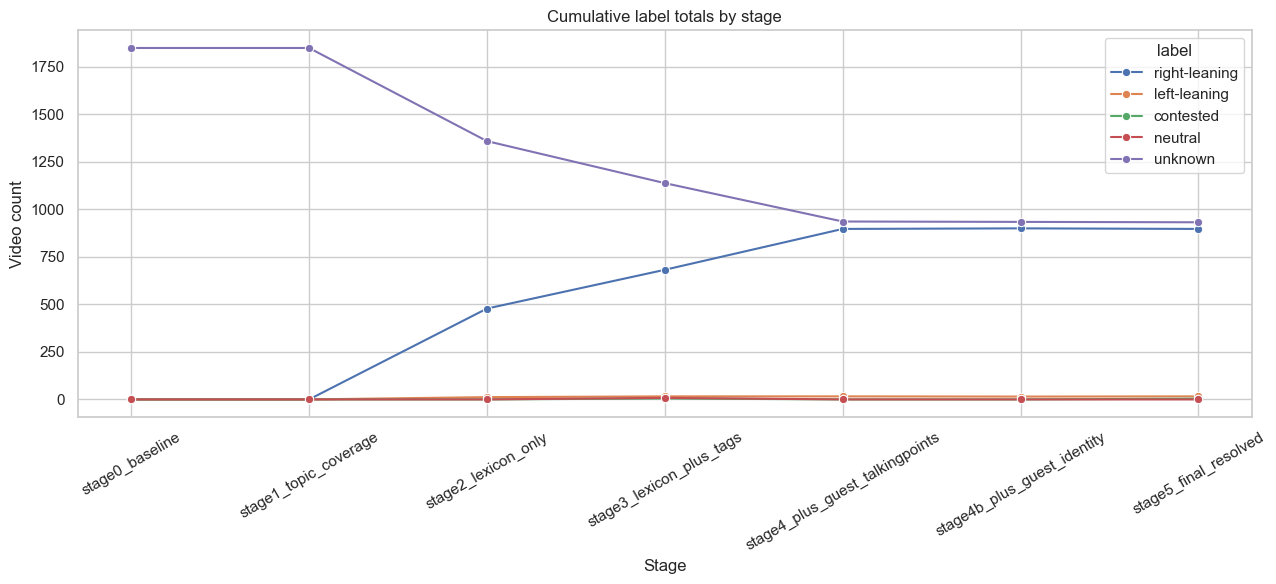

In [20]:
plot_df = summary[["stage"] + [f"{l}_count" for l in LABEL_ORDER]].copy()
long_df = plot_df.melt(id_vars="stage", var_name="label", value_name="count")
long_df["label"] = long_df["label"].str.replace("_count", "", regex=False)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=long_df, x="stage", y="count", hue="label", marker="o", ax=ax)
ax.set_title("Cumulative label totals by stage")
ax.set_xlabel("Stage")
ax.set_ylabel("Video count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


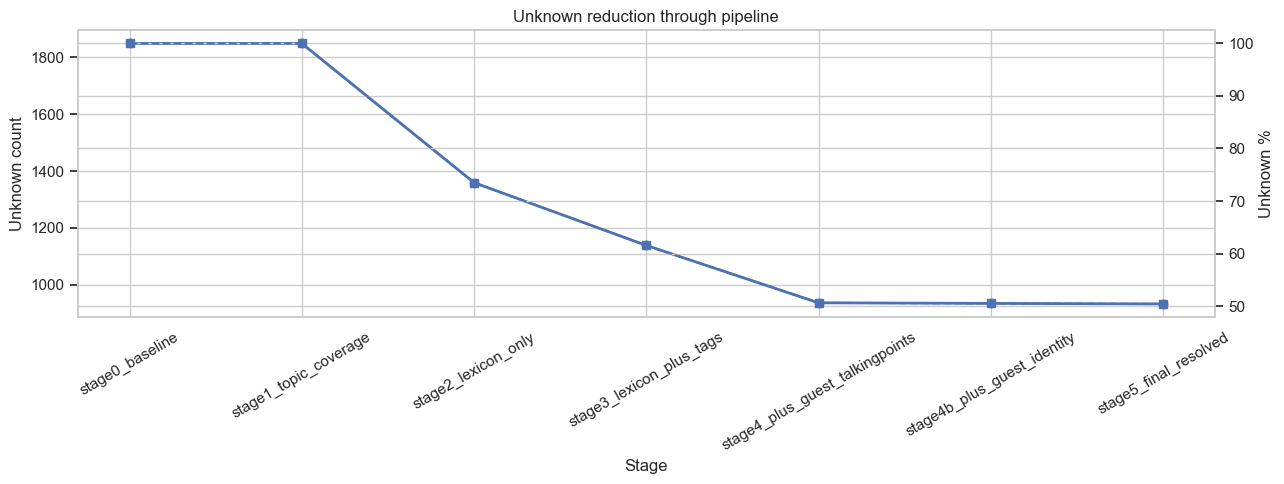

In [21]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(summary["stage"], summary["unknown_count"], marker="o", linewidth=2, label="Unknown count")
ax1.set_ylabel("Unknown count")
ax1.set_xlabel("Stage")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(summary["stage"], summary["unknown_pct"], marker="s", linestyle="--", label="Unknown %")
ax2.set_ylabel("Unknown %")

ax1.set_title("Unknown reduction through pipeline")
plt.tight_layout()
plt.show()


## 4 - Transition analysis: how labels move across stages


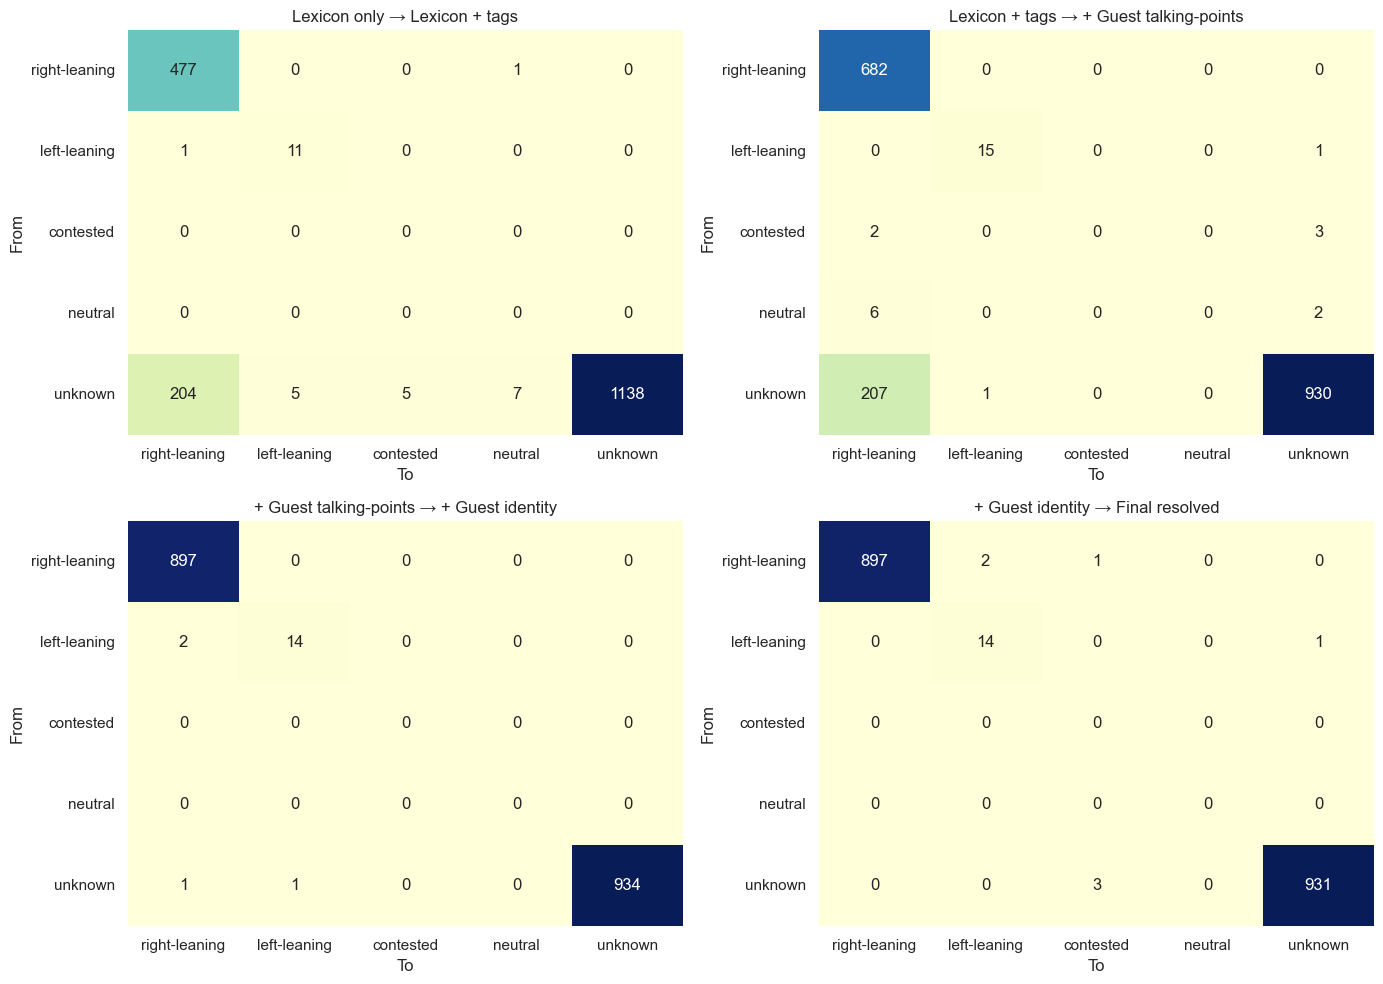

In [22]:
def transition_matrix(df, from_col, to_col):
    mat = pd.crosstab(df[from_col], df[to_col]).reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0)
    return mat

transitions = [
    ("label_stage2", "label_stage3", "Lexicon only → Lexicon + tags"),
    ("label_stage3", "label_stage4", "Lexicon + tags → + Guest talking-points"),
    ("label_stage4", "label_stage4b", "+ Guest talking-points → + Guest identity"),
    ("label_stage4b", "label_stage5", "+ Guest identity → Final resolved"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (src, dst, title) in zip(axes.flatten(), transitions):
    mat = transition_matrix(df, src, dst)
    sns.heatmap(mat, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("To")
    ax.set_ylabel("From")

plt.tight_layout()
plt.show()


## 5 - Signal contribution visuals


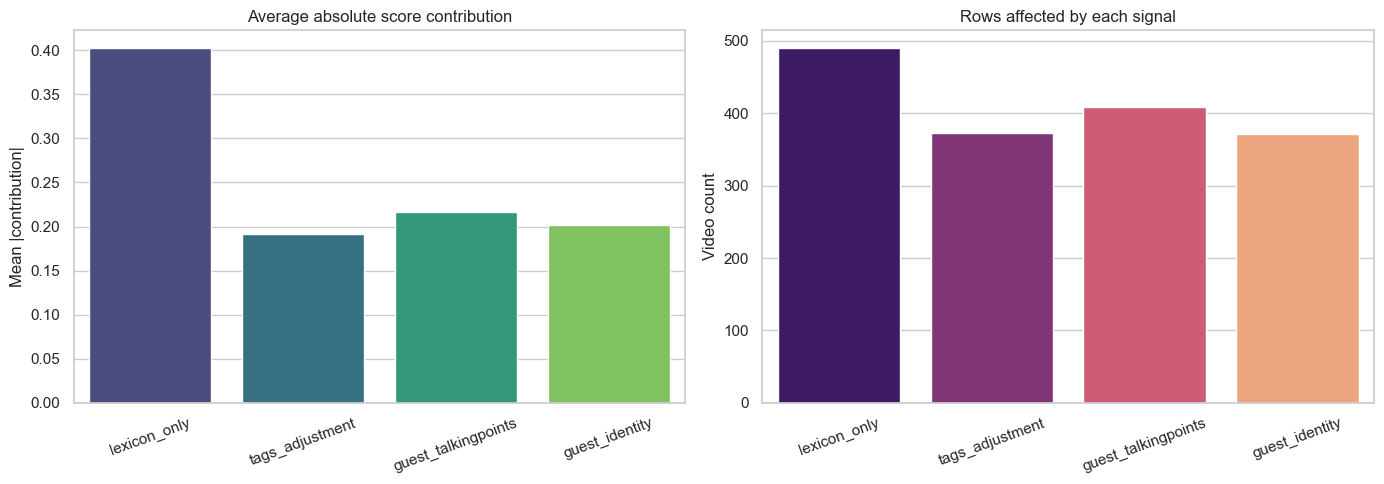

,component,mean_abs_contribution,nonzero_rows
0,lexicon_only,0.402380,490
1,tags_adjustment,0.191184,373
2,guest_talkingpoints,0.216739,408
3,guest_identity,0.201190,372


In [23]:
contrib = pd.DataFrame({
    "component": ["lexicon_only", "tags_adjustment", "guest_talkingpoints", "guest_identity"],
    "mean_abs_contribution": [
        (df["framing_score"] - df["tags_framing_score"]).abs().mean(),
        df["tags_framing_score"].abs().mean(),
        df["guest_signal"].abs().mean(),
        df["identity_signal"].abs().mean(),
    ],
    "nonzero_rows": [
        int(((df["framing_score"] - df["tags_framing_score"]) != 0).sum()),
        int((df["tags_framing_score"] != 0).sum()),
        int((df["guest_signal"] != 0).sum()),
        int((df["identity_signal"] != 0).sum()),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=contrib, x="component", y="mean_abs_contribution", ax=axes[0], palette="viridis", hue="component", legend=False)
axes[0].set_title("Average absolute score contribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean |contribution|")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=contrib, x="component", y="nonzero_rows", ax=axes[1], palette="magma", hue="component", legend=False)
axes[1].set_title("Rows affected by each signal")
axes[1].set_xlabel("")
axes[1].set_ylabel("Video count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

contrib


## 6 - Yearly trend of final labels


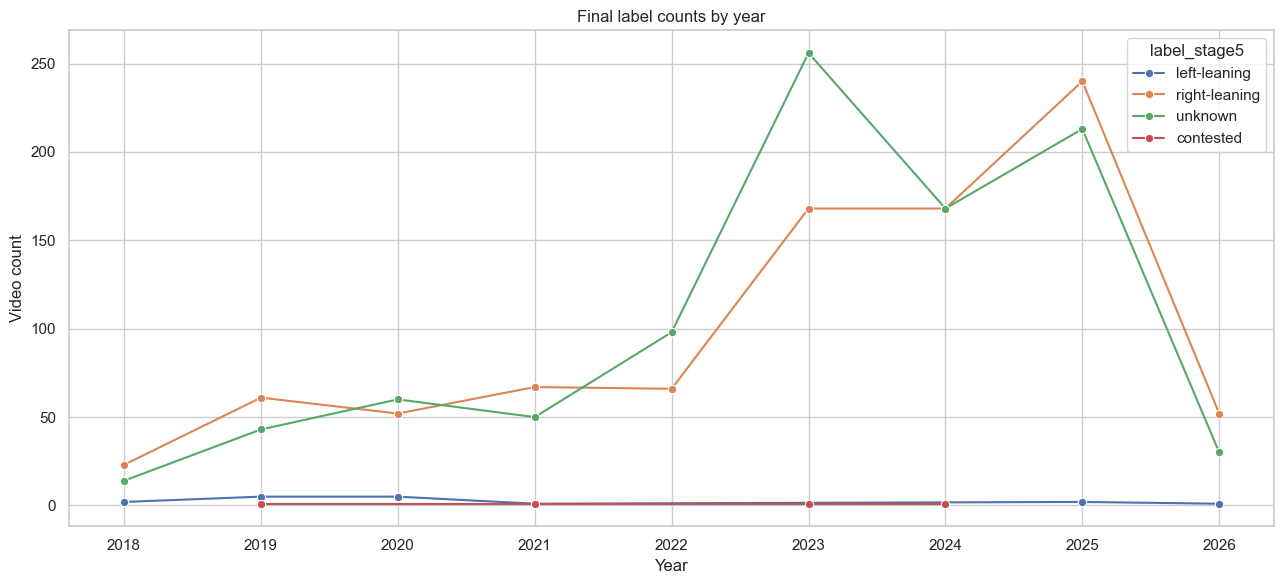

In [24]:
yearly = (
    df.assign(year=df["published_date"].dt.year)
      .groupby(["year", "label_stage5"])
      .size()
      .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=yearly, x="year", y="count", hue="label_stage5", marker="o", ax=ax)
ax.set_title("Final label counts by year")
ax.set_xlabel("Year")
ax.set_ylabel("Video count")
plt.tight_layout()
plt.show()


## 7 - Unknown review queue (persistent)

This surfaces unknowns for manual adjudication and keeps editable fields (`manual_label`, `manual_notes`).


In [25]:
if UNKNOWN_REVIEW_PATH.exists():
    unknown_review = pd.read_csv(UNKNOWN_REVIEW_PATH)
else:
    unknown_review = pd.DataFrame()

final_unknowns = df[df["label_stage5"] == "unknown"].copy()

print(f"Final unknown count: {len(final_unknowns):,}")
if not unknown_review.empty:
    print(f"Existing unknown review rows: {len(unknown_review):,}")

preview_cols = [c for c in [
    "published_date", "title", "guest_name_detected", "guest_signal",
    "signal_sources", "confidence", "combined_score"
] if c in final_unknowns.columns]

final_unknowns[preview_cols].head(25)


Final unknown count: 932
Existing unknown review rows: 932


,published_date,title,guest_name_detected,guest_signal,signal_sources,confidence,combined_score
0,2018-04-23,"Gideon Rachman on Trump, Russia, China, Israel...",Gideon Rachman,0.0,NaN,none,0.0
4,2018-05-14,"Dr Pippa Malmgren on Populism, Russia and AI",Dr Pippa Malmgren,0.0,NaN,none,0.0
5,2018-05-21,David Pilling on the Growth Delusion and Good ...,David Pilling,0.0,NaN,none,0.0
6,2018-05-28,"Peter Tatchell on Human Rights, Free Speech an...",Peter Tatchell,0.0,NaN,none,0.0
9,2018-06-18,"Dr Linda Yueh on Inequality, China and the End...",Dr Linda Yueh,0.0,NaN,none,0.0
10,2018-06-24,"Jeremy Shapiro on Trump, Trident, Israel & Iran",Jeremy Shapiro,0.0,NaN,none,0.0
16,2018-08-06,"Scott Capurro on Comedy, Offence and Politics ...",Scott Capurro,0.0,NaN,none,0.0
19,2018-08-31,TRIGGERnometry Read Mean Tweets,NaN,0.0,NaN,none,0.0
24,2018-09-30,"Kate Andrews on the Gender Pay Gap, Feminism, ...",Kate Andrews,0.0,NaN,none,0.0
26,2018-10-15,"Nicholas Gruen on Immigration, Corruption in A...",Nicholas Gruen,0.0,NaN,none,0.0


## 9 - Manual label override merge

Load curated `manual_label` values from `unknowns-review.csv` and apply them as overrides to the final classification. Only non-empty, valid labels will override automated results.

In [26]:
VALID_MANUAL_LABELS = {"right-leaning", "left-leaning", "contested", "neutral", "unknown"}

if UNKNOWN_REVIEW_PATH.exists():
    manual_df = pd.read_csv(UNKNOWN_REVIEW_PATH)
    print(f"Loaded unknowns-review.csv: {len(manual_df):,} rows")
else:
    manual_df = pd.DataFrame()
    print("No unknowns-review.csv found; manual override stage will be skipped.")

if not manual_df.empty and "manual_label" in manual_df.columns:
    manual_df["manual_label_raw"] = manual_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
    manual_df["manual_label_valid"] = manual_df["manual_label_raw"].where(
        manual_df["manual_label_raw"].isin(VALID_MANUAL_LABELS), ""
    )
    
    n_with_label = (manual_df["manual_label_valid"] != "").sum()
    n_invalid = ((manual_df["manual_label_raw"] != "") & (manual_df["manual_label_valid"] == "")).sum()
    
    print(f"Rows with valid manual_label: {n_with_label:,}")
    if n_invalid > 0:
        print(f"WARNING: {n_invalid:,} rows have invalid manual_label values (ignored)")
        invalid_examples = manual_df[
            (manual_df["manual_label_raw"] != "") & (manual_df["manual_label_valid"] == "")
        ]["manual_label_raw"].value_counts().head(5)
        print(f"  Invalid examples: {invalid_examples.to_dict()}")
else:
    manual_df["manual_label_valid"] = ""
    print("No manual_label column found or empty review file.")

Loaded unknowns-review.csv: 932 rows
Rows with valid manual_label: 0


In [27]:
def create_join_key(title, date):
    title_clean = str(title).strip().lower()
    date_str = str(date)[:10] if pd.notna(date) else ""
    return f"{title_clean}|{date_str}"

df["_join_key"] = df.apply(lambda r: create_join_key(r["title"], r["published_date"]), axis=1)

if not manual_df.empty and "title" in manual_df.columns:
    manual_df["_join_key"] = manual_df.apply(
        lambda r: create_join_key(r.get("title", ""), r.get("published_date", "")), axis=1
    )
    
    dup_keys = manual_df[manual_df["manual_label_valid"] != ""]["_join_key"].value_counts()
    dup_keys = dup_keys[dup_keys > 1]
    if len(dup_keys) > 0:
        print(f"WARNING: {len(dup_keys)} duplicate join keys in manual review (first label used)")
    
    manual_lookup = (
        manual_df[manual_df["manual_label_valid"] != ""]
        .drop_duplicates(subset="_join_key", keep="first")
        .set_index("_join_key")[["manual_label_valid"]]
    )
    if "manual_notes" in manual_df.columns:
        manual_lookup["manual_notes"] = (
            manual_df[manual_df["manual_label_valid"] != ""]
            .drop_duplicates(subset="_join_key", keep="first")
            .set_index("_join_key")["manual_notes"]
        )
    else:
        manual_lookup["manual_notes"] = ""
    
    df = df.join(manual_lookup, on="_join_key", how="left")
    df["manual_label_valid"] = df["manual_label_valid"].fillna("")
    df["manual_notes"] = df.get("manual_notes", pd.Series([""] * len(df))).fillna("")
else:
    df["manual_label_valid"] = ""
    df["manual_notes"] = ""

df["manual_override_applied"] = df["manual_label_valid"] != ""
df["combined_label_with_manual"] = df.apply(
    lambda r: r["manual_label_valid"] if r["manual_override_applied"] else r["label_stage5"],
    axis=1
)
df["manual_override_note"] = df["manual_notes"]

n_overrides = df["manual_override_applied"].sum()
print(f"\nManual overrides applied: {n_overrides:,}")
print(f"Unknown before manual: {(df['label_stage5'] == 'unknown').sum():,}")
print(f"Unknown after manual:  {(df['combined_label_with_manual'] == 'unknown').sum():,}")


Manual overrides applied: 0
Unknown before manual: 932
Unknown after manual:  932


In [28]:
label_stage6 = normalize_label(df["combined_label_with_manual"])
record_stage("stage6_manual_override", label_stage6, f"Manual overrides applied: {n_overrides:,}")

df["label_stage6"] = label_stage6

summary = stage_summary_df()
display(summary[["stage", "unknown_count", "unknown_pct", "delta_unknown", "note"]])

stage5_unknown = (df["label_stage5"] == "unknown").sum()
stage6_unknown = (df["label_stage6"] == "unknown").sum()
manual_unknown_reduction = stage5_unknown - stage6_unknown

print(f"\nStage 5 -> Stage 6 unknown reduction: {stage5_unknown:,} -> {stage6_unknown:,} ({manual_unknown_reduction:,} reclassified)")

if n_overrides > 0:
    print("\nTop manual overrides applied:")
    overridden = df[df["manual_override_applied"]][["title", "label_stage5", "combined_label_with_manual", "manual_override_note"]].head(10)
    overridden.columns = ["title", "before", "after", "note"]
    display(overridden)

,stage,unknown_count,unknown_pct,delta_unknown,note
0,stage0_baseline,1849,100.000000,0,All rows start unknown before any signal
1,stage1_topic_coverage,1849,100.000000,0,Topic presence measured; no directional label yet
2,stage2_lexicon_only,1359,73.499189,-490,Directional labels from title/description lexi...
3,stage3_lexicon_plus_tags,1138,61.546782,-221,Tags signal integrated
4,stage4_plus_guest_talkingpoints,936,50.621958,-202,Guest talking-points signal added
5,stage4b_plus_guest_identity,934,50.513791,-2,Guest identity signal added (372 matches)
6,stage5_final_resolved,932,50.405625,-2,Conflict/contested handling + final resolution
7,stage6_manual_override,932,50.405625,0,Manual overrides applied: 0



Stage 5 -> Stage 6 unknown reduction: 932 -> 932 (0 reclassified)


### Manual override impact visuals

In [29]:
if n_overrides > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    mat_manual = transition_matrix(df, "label_stage5", "label_stage6")
    sns.heatmap(mat_manual, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=axes[0])
    axes[0].set_title("Transition: stage5 -> stage6 (with manual)")
    axes[0].set_xlabel("After manual override")
    axes[0].set_ylabel("Before (automated)")
    
    override_dist = df[df["manual_override_applied"]]["combined_label_with_manual"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    sns.barplot(
        x=override_dist.index,
        y=override_dist.values,
        ax=axes[1],
        hue=override_dist.index,
        palette="Set2",
        dodge=False,
        legend=False,
    )
    axes[1].set_title(f"Manual overrides by target label (n={n_overrides:,})")
    axes[1].set_xlabel("Target label")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=30)
    
    plt.tight_layout()
    plt.show()
else:
    print("No manual overrides to visualize.")

No manual overrides to visualize.


## 10 - Export with manual overrides

Write a second classified CSV that includes manual override columns for downstream analysis.

In [30]:
EXPORT_WITH_MANUAL_PATH = DATA_DIR / "trigggerpod-classified-with-manual.csv"

export_cols_manual = [
    "published_date", "title", "url",
    "topics", "n_topics",
    "framing_score", "tags_framing_score", "guest_signal", "identity_signal",
    "guest_name_detected", "guest_style",
    "combined_score", "combined_label", "signal_sources", "confidence",
    "label_stage4b", "label_stage5", "label_stage6",
    "combined_label_with_manual",
    "manual_override_applied", "manual_override_note",
]

export_cols_available = [c for c in export_cols_manual if c in df.columns]
missing_export_cols = [c for c in export_cols_manual if c not in df.columns]
if missing_export_cols:
    print(f"Note: Missing columns for export (skipped): {missing_export_cols}")

export_df_manual = df[export_cols_available].copy()

assert len(export_df_manual) == len(df), "Row count mismatch in export!"

export_df_manual.to_csv(EXPORT_WITH_MANUAL_PATH, index=False)

final_counts = export_df_manual["combined_label_with_manual"].value_counts().reindex(LABEL_ORDER, fill_value=0)
print(f"Exported {len(export_df_manual):,} rows to {EXPORT_WITH_MANUAL_PATH.name}")
print(f"\nFinal label distribution (with manual overrides):")
for label in LABEL_ORDER:
    cnt = final_counts[label]
    pct = cnt / len(export_df_manual) * 100
    print(f"  {label:15s}: {cnt:>5,}  ({pct:5.1f}%)")

print(f"\nManual overrides applied: {n_overrides:,}")
print(f"Unknown remaining: {final_counts.get('unknown', 0):,}")

Exported 1,849 rows to trigggerpod-classified-with-manual.csv

Final label distribution (with manual overrides):
  right-leaning  :   897  ( 48.5%)
  left-leaning   :    16  (  0.9%)
  contested      :     4  (  0.2%)
  neutral        :     0  (  0.0%)
  unknown        :   932  ( 50.4%)

Manual overrides applied: 0
Unknown remaining: 932


## 11 - Stage method notes and audit checklist

### Method summary
- **Stage 0-1**: Baseline and topic coverage measurement
- **Stage 2 (Lexicon-only)**: Directional language in title/description
- **Stage 3 (Lexicon + tags)**: Metadata-level framing signals
- **Stage 4 (Guest talking-points)**: Guest signal based on topic overlap with known talking points
- **Stage 4b (Guest identity)**: Expanded guest identity classification from curated dictionary of 120+ known right/left/contested figures, including:
  - UK politicians (Conservative, Reform UK, Labour)
  - Right-wing media commentators (Douglas Murray, Peter Hitchens, etc.)
  - Gender critical activists (Helen Joyce, Kathleen Stock, etc.)
  - US right-wing media (Jordan Peterson, Ben Shapiro, Tucker Carlson, etc.)
  - COVID skeptics (Robert Malone, Jay Bhattacharya, etc.)
  - IDW figures (Eric Weinstein, Bret Weinstein)
  - Left-wing commentators (Aaron Bastani, Hasan Piker, etc.)
- **Stage 5 (Final automated)**: Conflict handling and uncertainty controls
- **Stage 6 (Manual override)**: Curated labels from `unknowns-review.csv`

### Output files
- `trigggerpod-classified.csv` — original automated classification (unchanged by this notebook)
- `trigggerpod-classified-with-manual.csv` — includes manual override columns + identity_signal
- `unknowns-review.csv` — editable review queue; fill `manual_label` and `manual_notes` columns

### Audit checklist
- Confirm unknown count trend is monotonic non-increasing after stage 2.
- Review transition heatmaps for unexpected jumps.
- Spot-check high-impact guests and terms each run.
- Continue manual review using `unknowns-review.csv`.
- Verify manual override counts match expectations after each edit cycle.
- Cross-reference guest identity matches with `04-guest-interview-bias.ipynb` dictionary.
